In [1]:
import qutip as qt
from qutip import *
import matplotlib.pyplot as plt
import numpy as np

## general solution for g(t)

In [2]:
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad
from scipy.special import gamma, zeta, eval_hermite, factorial

# Define parameters
kappa = 2.5e-3*2*np.pi*2

# Define sech function
def sech(x):
    return 1 / np.cosh(x)

_kappa_cache = {}

def _N_m(m, kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

def _compute_Z_m(m, A_coeffs, kappa):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = _N_m(Nj_index, kappa)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1 / Z

def _get_A_m(m, kappa):
    if kappa not in _kappa_cache:
        _kappa_cache[kappa] = {
            "A_list": {0: [1.0]},
            "Z_dict": {0: kappa / 4},
        }

    A_list = _kappa_cache[kappa]["A_list"]
    Z_dict = _kappa_cache[kappa]["Z_dict"]

    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = _get_A_m(lower_m, kappa)

        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = _N_m(m - (i + j), kappa)
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = _compute_Z_m(m, A_m_coeffs, kappa)
    Z_dict[m] = Z_m
    A_list[m] = A_m_coeffs
    return A_m_coeffs

def xi_m(t, m, kappa):
    A_coeffs = _get_A_m(m, kappa)
    Zm = _kappa_cache[kappa]["Z_dict"][m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

def hermite(x, n, kappa):
    x_scaled = np.sqrt(kappa) * x
    norm = np.sqrt(np.sqrt(kappa / np.pi)) / np.sqrt(2**n * factorial(n))
    psi = norm * eval_hermite(n, x_scaled) * np.exp(-x_scaled**2 / 2)
    return np.asarray(psi, dtype=np.float64) 

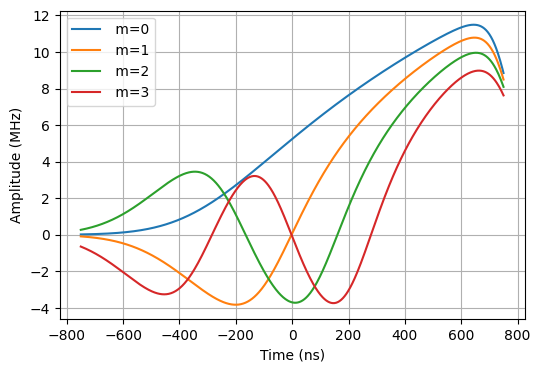

In [3]:

def f(t, m, kappa):
    # return xi_m(t, m, kappa)
    return hermite(t, m, kappa)

def f_prime(t, m, kappa, h=1e-3):
    return (f(t + h, m, kappa) - f(t - h, m, kappa)) / (2 * h)

def compute_g(t_vals, m, kappa, kappa_ph):
    f_vals = f(t_vals, m, kappa_ph)
    f_prime_vals = f_prime(t_vals, m, kappa_ph)
    

    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, t_vals, initial=0)
    
    numerator = f_prime_vals + (kappa * f_vals / 2)
    denominator = np.sqrt(kappa * (1 - integral_vals) - f2_vals)
    
    return numerator / denominator

kappa =  0.14*2*np.pi
# kappa_ph = 2.5e-3*2*np.pi*2
kappa_ph = 1.5e-6*2*np.pi*2
t_vals = np.linspace(-750, 750, 751)

plt.figure(figsize=(6, 4))
for m in range(4):
    g_vals = compute_g(t_vals, m, kappa, kappa_ph)
    plt.plot(t_vals, np.real(g_vals)/2/np.pi*1e3, label=fr" m={m}")

plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (MHz)")
plt.legend()
plt.grid(True)
plt.show()


## QuTiP simulation

In [4]:
from process_tomography import *
from state_tomography import *
from libys import qtp as ysq
from datataking import search_datadict_miyamura
from qutip import fidelity, Qobj
from analysis import (
    SpatiotemporalAnalysis,demodulate
)

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


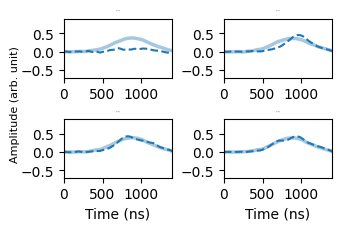

In [5]:
result_dict_tx = dict(
    data_ph0 = dict(target_freq=9.38, date="2025-07-22", acquire_time="101228", duration=1500),
    data_ph1 = dict(target_freq=9.38, date="2025-07-22", acquire_time="101338", duration=1500),
    data_ph2 = dict(target_freq=9.38, date="2025-07-22", acquire_time="101446", duration=1500),
    data_ph3 = dict(target_freq=9.38, date="2025-07-22", acquire_time="101555", duration=1500),
)

result_dict_rx = dict(
    data_ph0 = dict(target_freq=9.38, date="2025-07-22", acquire_time="104611", duration=1500),
    data_ph1 = dict(target_freq=9.38, date="2025-07-22", acquire_time="104718", duration=1500),
    data_ph2 = dict(target_freq=9.38, date="2025-07-22", acquire_time="104823", duration=1500),
    data_ph3 = dict(target_freq=9.38, date="2025-07-22", acquire_time="104930", duration=1500),
)

num_of_ph_amp = 1
num_of_fogi_timing = 51
f_if = (9.5-9.38)*1e9

header = "C:/Users/qipe/Documents/qutip_simulation/codes/data/CDK183/"
ph0_fo0 = "/2025-07-22/2025-07-22T110249_f7c23c9e-j1_JPA_comm_timing"
ph0_fo1 = "/2025-07-22/2025-07-22T113417_5d2f3e35-j1_JPA_comm_timing"
ph0_fo2 = "/2025-07-22/2025-07-22T120548_c4605a28-j1_JPA_comm_timing"
ph0_fo3 = "/2025-07-22/2025-07-22T123717_2a596d27-j1_JPA_comm_timing"
ph1_fo0 = "/2025-07-22/2025-07-22T130847_90efac8b-j1_JPA_comm_timing"
ph1_fo1 = "/2025-07-22/2025-07-22T134017_f799c07a-j1_JPA_comm_timing"
ph1_fo2 = "/2025-07-22/2025-07-22T141149_5f1db43e-j1_JPA_comm_timing"
ph1_fo3 = "/2025-07-22/2025-07-22T144320_c68575c6-j1_JPA_comm_timing"
ph2_fo0 = "/2025-07-22/2025-07-22T151453_2e70cbae-j1_JPA_comm_timing"
ph2_fo1 = "/2025-07-22/2025-07-22T154625_968513c0-j1_JPA_comm_timing"
ph2_fo2 = "/2025-07-22/2025-07-22T161801_0094b4c0-j1_JPA_comm_timing"
ph2_fo3 = "/2025-07-22/2025-07-22T164936_69cccf68-j1_JPA_comm_timing"
ph3_fo0 = "/2025-07-22/2025-07-22T172110_d2a95717-j1_JPA_comm_timing"
ph3_fo1 = "/2025-07-22/2025-07-22T175247_3d7855e2-j1_JPA_comm_timing"
ph3_fo2 = "/2025-07-22/2025-07-22T182424_a84928c8-j1_JPA_comm_timing"
ph3_fo3 = "/2025-07-22/2025-07-22T185602_13b52410-j1_JPA_comm_timing"


acquisition_00 = SpatiotemporalAnalysis(header, ph0_fo0, header, result_dict_tx['data_ph0'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_01 = SpatiotemporalAnalysis(header, ph0_fo1, header, result_dict_tx['data_ph0'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_02 = SpatiotemporalAnalysis(header, ph0_fo2, header, result_dict_tx['data_ph0'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_03 = SpatiotemporalAnalysis(header, ph0_fo3, header, result_dict_tx['data_ph0'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_10 = SpatiotemporalAnalysis(header, ph1_fo0, header, result_dict_tx['data_ph1'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_11 = SpatiotemporalAnalysis(header, ph1_fo1, header, result_dict_tx['data_ph1'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_12 = SpatiotemporalAnalysis(header, ph1_fo2, header, result_dict_tx['data_ph1'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_13 = SpatiotemporalAnalysis(header, ph1_fo3, header, result_dict_tx['data_ph1'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_20 = SpatiotemporalAnalysis(header, ph2_fo0, header, result_dict_tx['data_ph2'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_21 = SpatiotemporalAnalysis(header, ph2_fo1, header, result_dict_tx['data_ph2'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_22 = SpatiotemporalAnalysis(header, ph2_fo2, header, result_dict_tx['data_ph2'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_23 = SpatiotemporalAnalysis(header, ph2_fo3, header, result_dict_tx['data_ph2'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_30 = SpatiotemporalAnalysis(header, ph3_fo0, header, result_dict_tx['data_ph3'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_31 = SpatiotemporalAnalysis(header, ph3_fo1, header, result_dict_tx['data_ph3'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_32 = SpatiotemporalAnalysis(header, ph3_fo2, header, result_dict_tx['data_ph3'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_33 = SpatiotemporalAnalysis(header, ph3_fo3, header, result_dict_tx['data_ph3'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)

ph_amp = 0
fogi_freq = 5
fig, axs = plt.subplots(2, 2, figsize=(3.2, 2.2) , constrained_layout=True) 
acquisition_00.plot_waveform(ax=axs[0, 0], title="(0, 0)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq, show_title=False, mode=0)
acquisition_01.plot_waveform(ax=axs[0, 1], title="(0, 1)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq, show_title=False, mode=0)
acquisition_02.plot_waveform(ax=axs[1, 0], title="(0, 2)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq, show_title=False, mode=0)
acquisition_03.plot_waveform(ax=axs[1, 1], title="(0, 3)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq, show_title=False, mode=0)
fig.text(-0.02, 0.55, "Amplitude (arb. unit)", va="center", rotation="vertical")
for ax in axs[-1, :]:
    ax.set_xlabel("Time (ns)")
# plt.tight_layout()
plt.show()

In [6]:
acquisitions = [[None for _ in range(4)] for _ in range(4)]

acquisitions[0][0] = acquisition_00
acquisitions[0][1] = acquisition_01
acquisitions[0][2] = acquisition_02
acquisitions[0][3] = acquisition_03

acquisitions[1][0] = acquisition_10
acquisitions[1][1] = acquisition_11
acquisitions[1][2] = acquisition_12
acquisitions[1][3] = acquisition_13

acquisitions[2][0] = acquisition_20
acquisitions[2][1] = acquisition_21
acquisitions[2][2] = acquisition_22
acquisitions[2][3] = acquisition_23

acquisitions[3][0] = acquisition_30
acquisitions[3][1] = acquisition_31
acquisitions[3][2] = acquisition_32
acquisitions[3][3] = acquisition_33

### photon emission

In [7]:
n_cutoff_q = 3
n_cutoff_r = 2
n_cutoff_vc = 3

b = qt.tensor(qt.destroy(n_cutoff_q), qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
a = qt.tensor(qt.qeye(n_cutoff_q), qt.destroy(n_cutoff_r), qt.qeye(n_cutoff_vc))
vc = qt.tensor(qt.qeye(n_cutoff_q), qt.qeye(n_cutoff_r), qt.destroy(n_cutoff_vc))

zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[0,1]=1
gedecayop=Qobj(zeromatrixxtmp)
etog = qt.tensor(gedecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[1,2]=1
efdecayop=Qobj(zeromatrixxtmp)
ftoe = qt.tensor(efdecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[0,0]=-1
zeromatrixxtmp[1,1]=1
gedechoop=Qobj(zeromatrixxtmp)
dechoge = qt.tensor(gedechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[1,1]=-1
zeromatrixxtmp[2,2]=1
efdechoop=Qobj(zeromatrixxtmp)
dechoef = qt.tensor(efdechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))

g0 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
f0 = qt.tensor(qt.basis(n_cutoff_q, 2), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
g1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 1), qt.basis(n_cutoff_vc, 0))
e0 = qt.tensor(qt.basis(n_cutoff_q, 1), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
vc1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 1))

alpha = -0.356 * 2 * np.pi
chi = -0.0076 * 2 * np.pi
eta = 0.67
kappa_r = 0.14 * 2 * np.pi
K = 0 * 2 * np.pi

H_fogi = (
    -alpha / 2 * b.dag()*b + alpha * b.dag()*b.dag()*b*b / 2
    +K * a.dag()*a.dag()*a*a / 2 + 2*chi*a.dag()*a*b.dag()*b
)

H_d = -a.dag()*b*b/np.sqrt(2)
H_c = 1j * (np.sqrt(kappa_r)/2) * vc.dag()*a

T1ge=29*1e3
T1ef=22*1e3
T2ge=5*1e3
T2ef=5*1e3
Tphige=1/((1/T2ge-1/T1ge/2)/2)
Tphief=1/((1/T2ef-1/T1ef/2)/2)

e_ops = []
options = qt.Options(atol=1e-9, rtol=1e-9, nsteps=1000, max_step=0.1, store_states=True)

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


In [8]:
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d

T = 750 
N = 751
tgrid = np.linspace(-T, T, N)
dt = tgrid[1] - tgrid[0]
# kappa_ph = 2.5e-3 * 2 * np.pi * 2

_eps = 1e-14

g_interps = []
g_interps_rvs = []

for m in range(4): 
    f_vals = f(tgrid, m, kappa_ph)
    f_prime_vals = f_prime(tgrid, m, kappa_ph) 
    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, tgrid, initial=0)

    numerator = f_prime_vals + (kappa_r * f_vals / 2)
    denominator = np.sqrt(kappa_r * (1.0 - integral_vals) - f2_vals)
    g_vals = numerator / denominator
    g_interp = interp1d(tgrid, np.real(g_vals), kind='cubic', fill_value='extrapolate')
    g_interps.append(g_interp)

    g_interp_rvs = interp1d(tgrid, np.real(g_vals[::-1]), kind='cubic', fill_value='extrapolate') 
    g_interps_rvs.append(g_interp_rvs)
    
g_u_interps = []
for m in range(4):
    # ut_vals = xi_m(tgrid, m, kappa_ph)
    ut_vals = hermite(tgrid, m, kappa_ph)
    cumint = cumulative_trapezoid(np.abs(ut_vals)**2, tgrid, initial=0)
    eps = 1e-14
    denom = np.sqrt(1.0 - cumint + eps)
    g_vals = np.conjugate(ut_vals) / denom
    g_interp = interp1d(tgrid, g_vals, kind='cubic', fill_value='extrapolate')
    g_u_interps.append(g_interp)

def g_u(t, args):
    m = int(args["input_num"])
    t_local = float(t)
    return float(args["g_u_interps"][m](t_local))

def g_u_conj(t, args):
    return np.conjugate(g_u(t, args))

def g_time(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps"][m](t_local))

def g_time_conj(t, args):
    return np.conjugate(g_time(t, args))

def g_time_rvs(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps_rvs"][m](t_local))

def g_time_conj_rvs(t, args):
    return np.conjugate(g_time_rvs(t, args))

In [9]:
base_args = {
    "center": 0.0,
    "fogi_mode": 2,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "input_num": 0,
    "input": 0,
}
results = {} 

for m in range(4):
    args_m = base_args.copy()
    args_m["fogi_mode"] = m

    H_m = [
        H_fogi,
        [H_d, g_time], [H_d.dag(), g_time_conj],
    ]
    psi0_m = (g0 + f0).unit()


    def total_c_op(t, args):
        c_op = np.sqrt(kappa_r) * a
        return c_op

    c_ops_m = [
        total_c_op,
        np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
        np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
    ]

    result_m = qt.mesolve(
        H_m, psi0_m, tgrid, c_ops_m, e_ops=e_ops,
        args=args_m, options=options, progress_bar=True
    )

    results[m] = result_m
    print(f"mode {m} finished")
# Extract states

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\solver_base.py:460: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


10.0%. Run time:   0.73s. Est. time left: 00:00:00:06
20.0%. Run time:   1.31s. Est. time left: 00:00:00:05
30.0%. Run time:   1.98s. Est. time left: 00:00:00:04
40.0%. Run time:   2.59s. Est. time left: 00:00:00:03
50.0%. Run time:   3.21s. Est. time left: 00:00:00:03
60.0%. Run time:   4.20s. Est. time left: 00:00:00:02
70.0%. Run time:   4.83s. Est. time left: 00:00:00:02
80.0%. Run time:   5.42s. Est. time left: 00:00:00:01
90.0%. Run time:   6.06s. Est. time left: 00:00:00:00
100.0%. Run time:   7.07s. Est. time left: 00:00:00:00
Total run time:   7.07s
mode 0 finished
10.0%. Run time:   1.01s. Est. time left: 00:00:00:09
20.0%. Run time:   1.80s. Est. time left: 00:00:00:07
30.0%. Run time:   2.51s. Est. time left: 00:00:00:05
40.0%. Run time:   3.40s. Est. time left: 00:00:00:05
50.0%. Run time:   4.24s. Est. time left: 00:00:00:04
60.0%. Run time:   5.04s. Est. time left: 00:00:00:03
70.0%. Run time:   6.04s. Est. time left: 00:00:00:02
80.0%. Run time:   7.37s. Est. time left:

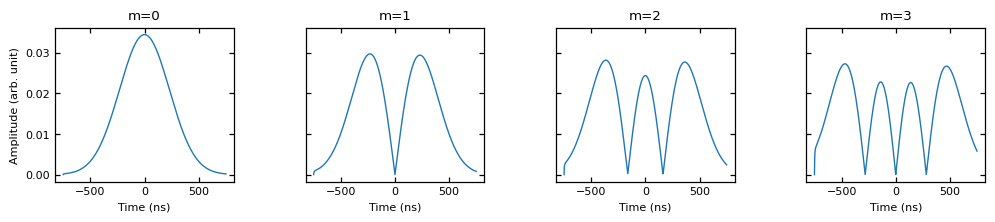

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(12, 2), sharey=True)
plt.subplots_adjust(wspace=0.4)

# Input operators
for i in range(4):
    states = results[i].states
    vcdvc_s = qt.expect(vc.dag() * vc, states)
    ada_s = qt.expect(a.dag() * a, states)
    vcda_s = qt.expect(vc.dag() * a, states)
    advc_s = qt.expect(a.dag() * vc, states)
    gu_values = np.array([g_u(t, base_args) for t in tgrid])
    LdL = (
        gu_values * np.conjugate(gu_values) * vcdvc_s
        + kappa_r * ada_s
        + np.sqrt(kappa_r) * (gu_values * vcda_s + np.conjugate(gu_values) * advc_s)
    )
    axes[i].plot(tgrid, np.sqrt(LdL), label="photon waveform")
    axes[i].set_title(f"m={i}")
    axes[i].set_xlabel(r"Time (ns)")
    if i == 0:
        axes[i].set_ylabel("Amplitude (arb. unit)")
plt.show()

### photon absorption

In [11]:
base_args = {
    "center": 0.0,
    "fogi_mode": 0,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "input_num": 0,
    "input": 1,
}
results = {} 

for m in range(4):
    args_mn = base_args.copy()
    args_mn["input_num"] = m

    for n in range(4):
        args_mn["fogi_mode"] = n
        H_m = [
            H_fogi,
            [H_c, g_u], [H_c.dag(), g_u_conj],
            [H_d, g_time_rvs], [H_d.dag(), g_time_conj_rvs],
        ]
        psi0_m = vc1

        def total_c_op(t, args):
            c_op = np.conjugate(g_u(t, args)) * vc + np.sqrt(kappa_r) * a
            return c_op

        c_ops_mn = [
            total_c_op,
            np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
            np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
        ]

        result_mn = qt.mesolve(
            H_m, psi0_m, tgrid, c_ops_mn, e_ops=e_ops,
            args=args_mn, options=options, progress_bar=True
        )

        results[(m, n)] = result_mn 
    print(f"mode {m} finished")


10.0%. Run time:   0.77s. Est. time left: 00:00:00:06
20.0%. Run time:   1.44s. Est. time left: 00:00:00:05
30.0%. Run time:   2.24s. Est. time left: 00:00:00:05
40.0%. Run time:   3.36s. Est. time left: 00:00:00:05
50.0%. Run time:   4.35s. Est. time left: 00:00:00:04
60.0%. Run time:   5.21s. Est. time left: 00:00:00:03
70.0%. Run time:   5.91s. Est. time left: 00:00:00:02
80.0%. Run time:   6.63s. Est. time left: 00:00:00:01
90.0%. Run time:   7.39s. Est. time left: 00:00:00:00
100.0%. Run time:   8.22s. Est. time left: 00:00:00:00
Total run time:   8.22s
10.0%. Run time:   0.67s. Est. time left: 00:00:00:06
20.0%. Run time:   1.34s. Est. time left: 00:00:00:05
30.0%. Run time:   1.99s. Est. time left: 00:00:00:04
40.0%. Run time:   2.78s. Est. time left: 00:00:00:04
50.0%. Run time:   3.44s. Est. time left: 00:00:00:03
60.0%. Run time:   4.11s. Est. time left: 00:00:00:02
70.0%. Run time:   4.77s. Est. time left: 00:00:00:02
80.0%. Run time:   5.41s. Est. time left: 00:00:00:01
90.

best_x: [-1.45173259e-02  6.24465829e+01]
best_x: [-7.52527776e-03  3.99954841e+01]
best_x: [-8.12271524e-03  3.65424847e+01]
best_x: [-8.12897919e-03  3.38447464e+01]


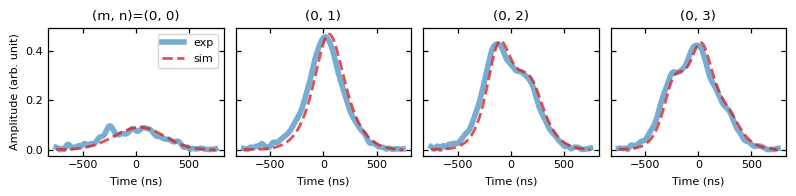

best_x: [6.03215532e-03 3.28848893e+01]
best_x: [-6.66396499e-03  3.99999115e+01]
best_x: [-7.38044279e-03  3.97058475e+01]
best_x: [-7.73001642e-03  3.59999745e+01]


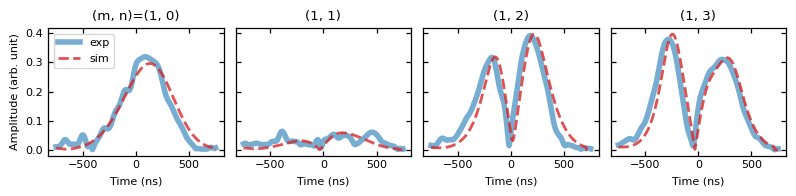

best_x: [-6.78173736e-03  2.95303298e+01]
best_x: [-7.14989853e-03  2.96231601e+01]
best_x: [-9.34626049e-03  3.59999993e+01]
best_x: [6.67348599e-03 4.14002094e+01]


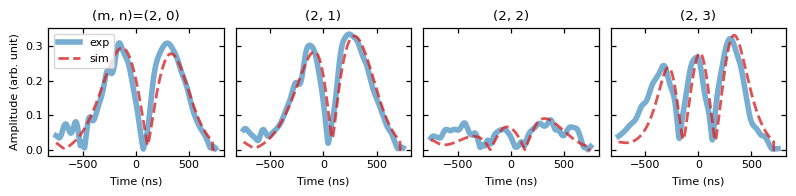

best_x: [6.50946478e-03 3.50000907e+01]
best_x: [-6.90673134e-03  3.60000026e+01]
best_x: [-7.53021800e-03  3.12291809e+01]
best_x: [-1.18236195e-02  3.89999045e+01]


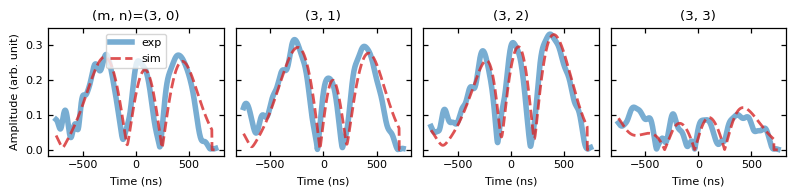

In [12]:
from scipy import interpolate, optimize
from scipy.ndimage import shift as nd_shift

def fit_waveform(time, waveform_exp, waveform_sim, x0=[1.0, 0.0]):

    def func(params):
        scale, shift = params
        sim_shifted = roll_with_interpolation(waveform_sim, shift=-shift)
        return scale * sim_shifted

    def cost_func(params):
        return np.linalg.norm(np.abs(func(params)) - np.abs(waveform_exp))

    best_x = optimize.minimize(cost_func, x0, method='Nelder-Mead').x
    print("best_x:", best_x)

    fitted = func(best_x)
    return fitted, best_x

def roll_with_interpolation(array, shift):
    return nd_shift(array, shift=shift, mode='constant', cval=0.0)

for m in range(4):    
    fig, axes = plt.subplots(1, 4, figsize=(8, 2), sharey=True)
    plt.subplots_adjust(wspace=0.4)

    for n in range(4):
        states = results[(m, n)].states
        vcdvc_s = qt.expect(vc.dag() * vc, states)
        ada_s = qt.expect(a.dag() * a, states)
        vcda_s = qt.expect(vc.dag() * a, states)
        advc_s = qt.expect(a.dag() * vc, states)
        args = {
            "center": 0.0,
            "fogi_mode": n,
            "g_interps": g_interps,
            "g_interps_rvs": g_interps_rvs,
            "g_u_interps": g_u_interps,
            "input_num": m,
            "input": 0,
        }  

        gu_values = np.array([g_u(t, args) for t in tgrid])
        LdL = (
            gu_values * np.conjugate(gu_values) * vcdvc_s
            + kappa_r * ada_s
            + np.sqrt(kappa_r) * (gu_values * vcda_s + np.conjugate(gu_values) * advc_s)
        )
        abs_exp = acquisitions[m][n].get_results()["y_absorbed_signals"][ph_amp][fogi_freq][100:-149]
        fitted_dummy, best_x = fit_waveform(tgrid, np.abs(abs_exp), np.sqrt(LdL), x0=[1.0, 10.0])
        scale, shift_val = best_x
        def apply_fit(waveform, scale, shift_val, time):
            waveform_resampled = np.interp(time, np.linspace(time[0], time[-1], len(waveform)), waveform)
            dt = time[1] - time[0]
            shift_idx = -shift_val / dt 
            return scale * nd_shift(waveform_resampled, shift=shift_idx, mode='constant', cval=0.0)
        
        fitted_abs_sim = apply_fit(np.sqrt(LdL), scale, shift_val, tgrid)
            
        axes[n].plot(tgrid, np.abs(abs_exp)*1e3, lw=4, alpha=0.6, color="tab:blue", label="exp")
        axes[n].plot(tgrid, np.abs(fitted_abs_sim)*1e3, lw=2, alpha=0.8, linestyle="--", color="tab:red", label="sim")
        
        axes[n].set_xlabel(r"Time (ns)")
        if n == 0:
            axes[n].legend()
            axes[n].set_ylabel("Amplitude (arb. unit)")
            axes[n].set_title(f"(m, n)=({m}, {n})")
        else:
            axes[n].set_title(f"({m}, {n})")
    plt.tight_layout()
    plt.show()

## Mode conversion - delay opt

In [13]:
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d

T = 1000 
N = 1001
tgrid = np.linspace(-T, T, N)
dt = tgrid[1] - tgrid[0]
# kappa_ph = 2.5e-3 * 2 * np.pi * 2

_eps = 1e-14

g_interps = []
g_interps_rvs = []

for m in range(8): 
    f_vals = f(tgrid, m, kappa_ph)
    f_prime_vals = f_prime(tgrid, m, kappa_ph) 
    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, tgrid, initial=0)

    numerator = f_prime_vals + (kappa_r * f_vals / 2)
    denominator = np.sqrt(kappa_r * (1.0 - integral_vals) - f2_vals)
    g_vals = numerator / denominator
    g_interp = interp1d(tgrid, np.real(g_vals), kind='cubic', fill_value='extrapolate')
    g_interps.append(g_interp)

    g_interp_rvs = interp1d(tgrid, np.real(g_vals[::-1]), kind='cubic', fill_value='extrapolate') 
    g_interps_rvs.append(g_interp_rvs)
    
g_u_interps = []
for m in range(8):
    # ut_vals = xi_m(tgrid, m, kappa_ph)
    ut_vals = hermite(tgrid, m, kappa_ph)
    cumint = cumulative_trapezoid(np.abs(ut_vals)**2, tgrid, initial=0)
    eps = 1e-14
    denom = np.sqrt(1.0 - cumint + eps)
    g_vals = np.conjugate(ut_vals) / denom
    g_interp = interp1d(tgrid, g_vals, kind='cubic', fill_value='extrapolate')
    g_u_interps.append(g_interp)

def g_u(t, args):
    m = int(args["input_num"])
    t_local = float(t)
    return float(args["g_u_interps"][m](t_local))

def g_u_conj(t, args):
    return np.conjugate(g_u(t, args))

def g_time(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps"][m](t_local))

def g_time_conj(t, args):
    return np.conjugate(g_time(t, args))

def g_time_rvs(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps_rvs"][m](t_local))

def g_time_conj_rvs(t, args):
    return np.conjugate(g_time_rvs(t, args))

In [14]:
base_args = {
    "center": 0.0,
    "fogi_mode": 0,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "input_num": 0,
    "input": 1,
}
results = {} 

for m in range(8):
    args_mn = base_args.copy()
    args_mn["input_num"] = m
    n=0

    H_m = [
        H_fogi,
        [H_c, g_u], [H_c.dag(), g_u_conj],
        [H_d, g_time_rvs], [H_d.dag(), g_time_conj_rvs],
    ]
    psi0_m = vc1

    def total_c_op(t, args):
        c_op = np.conjugate(g_u(t, args)) * vc + np.sqrt(kappa_r) * a
        return c_op

    c_ops_mn = [
        total_c_op,
        np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
        np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
    ]

    result_mn = qt.mesolve(
        H_m, psi0_m, tgrid, c_ops_mn, e_ops=e_ops,
        args=args_mn, options=options, progress_bar=True
    )

    results[(m, n)] = result_mn 
    print(f"mode {m} finished")


10.0%. Run time:  22.37s. Est. time left: 00:00:03:21
20.0%. Run time:  45.47s. Est. time left: 00:00:03:01
30.0%. Run time:  68.46s. Est. time left: 00:00:02:39
40.0%. Run time:  89.28s. Est. time left: 00:00:02:13
50.0%. Run time: 110.07s. Est. time left: 00:00:01:50
60.0%. Run time: 131.40s. Est. time left: 00:00:01:27
70.0%. Run time: 152.53s. Est. time left: 00:00:01:05
80.0%. Run time: 174.81s. Est. time left: 00:00:00:43
90.0%. Run time: 195.21s. Est. time left: 00:00:00:21
100.0%. Run time: 215.91s. Est. time left: 00:00:00:00
Total run time: 215.91s
mode 0 finished
10.0%. Run time:  20.38s. Est. time left: 00:00:03:03
20.0%. Run time:  41.35s. Est. time left: 00:00:02:45
30.0%. Run time:  59.49s. Est. time left: 00:00:02:18
40.0%. Run time:  79.31s. Est. time left: 00:00:01:58
50.0%. Run time: 101.49s. Est. time left: 00:00:01:41
60.0%. Run time: 124.98s. Est. time left: 00:00:01:23
70.0%. Run time: 146.23s. Est. time left: 00:00:01:02
80.0%. Run time: 168.33s. Est. time left:

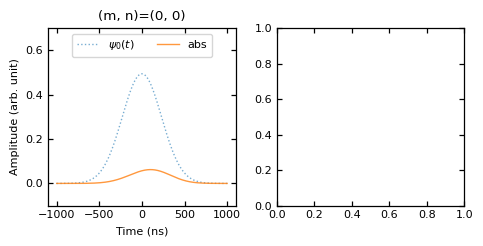

best_x: [-150.]


C:\Users\qipe\AppData\Local\Temp\ipykernel_12848\1324177248.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  overlap = np.trapz(np.conjugate(psi_prime) * shifted, dx=dt)


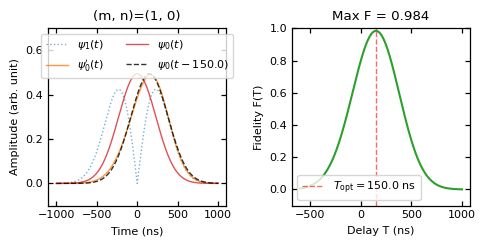

best_x: [-131.]


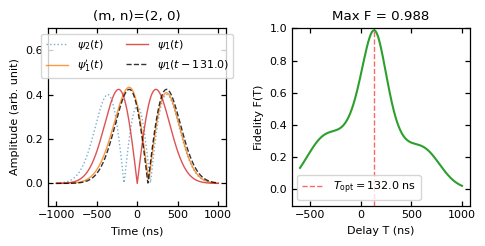

best_x: [-113.]


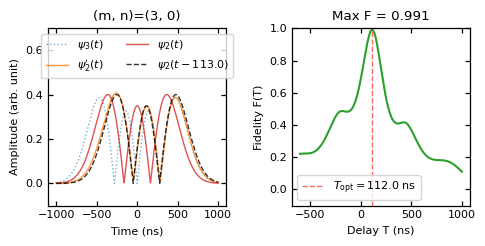

best_x: [-100.]


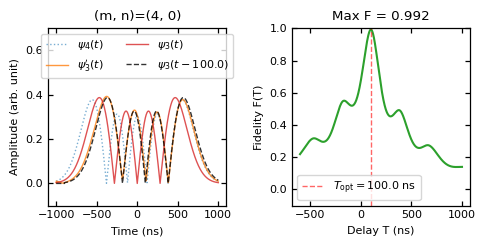

best_x: [-91.]


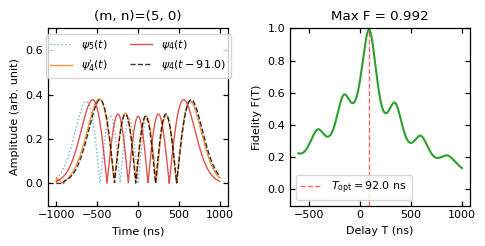

best_x: [-84.]


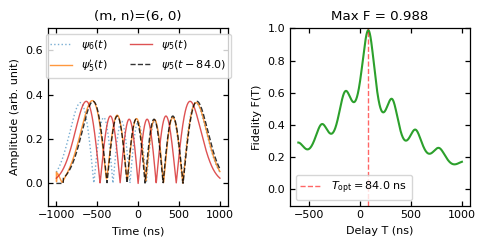

best_x: [-79.]


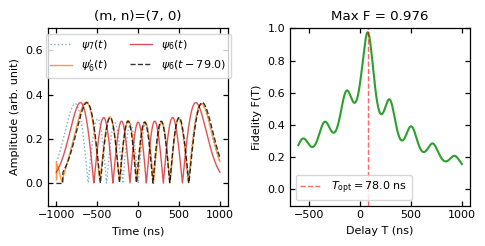

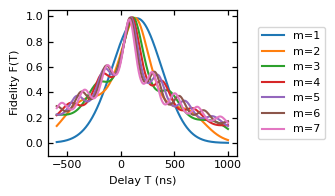

In [15]:
def fit_delay(time, waveform_exp, waveform_sim, x0=[0.0]):
    def func(params):
        shift = params
        sim_shifted = roll_with_interpolation(waveform_sim, shift=-shift)
        return sim_shifted

    def cost_func(params):
        return np.linalg.norm(np.abs(func(params)) - np.abs(waveform_exp))

    best_x = optimize.minimize(cost_func, x0, method='Nelder-Mead').x
    print("best_x:", np.round(best_x*2, 0))

    fitted = func(best_x)
    return fitted, best_x

def fidelity_vs_delay(tgrid, psi_prime, psi_target, T_vals):
    """
    F(T) = |∫ psi'(t) * psi(t - T) dt|^2
    """
    dt = tgrid[1] - tgrid[0]
    F_list = []
    for T in T_vals:
        shifted = np.interp(tgrid, tgrid - T, psi_target, left=0.0, right=0.0)
        overlap = np.trapz(np.conjugate(psi_prime) * shifted, dx=dt)
        F_list.append(np.abs(overlap)**2)
    return np.array(F_list)

all_F_vals = []
mode_labels = []

for m in range(8):    
    fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
    plt.subplots_adjust(wspace=0.4)

    n=0
    states = results[(m, n)].states
    vcdvc_s = qt.expect(vc.dag() * vc, states)
    ada_s = qt.expect(a.dag() * a, states)
    vcda_s = qt.expect(vc.dag() * a, states)
    advc_s = qt.expect(a.dag() * vc, states)
    args = {
        "center": 0.0,
        "fogi_mode": n,
        "g_interps": g_interps,
        "g_interps_rvs": g_interps_rvs,
        "g_u_interps": g_u_interps,
        "input_num": m,
        "input": 0,
    }  

    gu_values = np.array([g_u(t, args) for t in tgrid])
    LdL = (
        gu_values * np.conjugate(gu_values) * vcdvc_s
        + kappa_r * ada_s
        + np.sqrt(kappa_r) * (gu_values * vcda_s + np.conjugate(gu_values) * advc_s)
    )
    input_xi = hermite(tgrid, m, kappa_ph)
    
    axes[0].plot(tgrid, np.abs(input_xi)*1e1, lw=1, alpha=0.6, color="tab:blue", linestyle=":", label=rf"$\psi_{m}(t)$")
    if m ==0:
        axes[0].plot(tgrid, np.abs(np.sqrt(LdL))*1e1, lw=1, alpha=0.8, color="tab:orange", label="abs")
    if m > 0:
        axes[0].plot(tgrid, np.abs(np.sqrt(LdL))*1e1, lw=1, alpha=0.8, color="tab:orange", label=rf"$\psi_{m-1}'(t)$")
        shifted_xi = hermite(tgrid, m-1, kappa_ph)
        axes[0].plot(tgrid, np.abs(shifted_xi)*1e1, lw=1, alpha=0.8, color="tab:red", label= rf"$\psi_{m-1}(t)$")

        fitted_dummy, best_x = fit_delay(tgrid, np.sqrt(LdL), shifted_xi, x0=[-50])
        shift_val = best_x
        def apply_fit(waveform, shift_val, time):
            waveform_resampled = np.interp(time, np.linspace(time[0], time[-1], len(waveform)), waveform)
            dt = time[1] - time[0]
            shift_idx = -shift_val / dt 
            return nd_shift(waveform_resampled, shift=shift_idx, mode='constant', cval=0.0)
        
        delay_opt_waveform = apply_fit(shifted_xi, shift_val*2, tgrid)
        axes[0].plot(tgrid, np.abs(delay_opt_waveform)*1e1, lw=1, alpha=0.8, color="black", linestyle="--", label=rf"$\psi_{m-1}(t{round(shift_val[0]*2, 0)})$")

        T_vals = np.linspace(-600, 1000, 801)  # ns範囲
        F_vals = fidelity_vs_delay(tgrid, np.sqrt(LdL), np.abs(shifted_xi), -T_vals)
        all_F_vals.append(F_vals)
        mode_labels.append(f"m={m}")
        axes[1].plot(T_vals, F_vals, lw=1.5, color="tab:green")
        axes[1].set_xlabel("Delay T (ns)")
        axes[1].set_ylabel("Fidelity F(T)")
        axes[1].set_ylim(-0.1, 1)
        axes[1].set_title("Fidelity vs Delay")
        F_max = F_vals.max()
        T_opt = T_vals[F_vals.argmax()]
        axes[1].axvline(T_opt, color="red", linestyle="--", alpha=0.6, label=fr"$T_\mathrm{{opt}}={T_opt:.1f}$ ns")
        axes[1].legend(loc="lower left",)
        axes[1].set_title(fr"Max F = {F_max:.3f}")
     
    axes[0].set_xlabel(r"Time (ns)")
    axes[0].set_ylim(-0.1, 0.7)
    if n == 0:
        axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1), ncol=2)
        axes[0].set_ylabel("Amplitude (arb. unit)")
        axes[0].set_title(f"(m, n)=({m}, {n})")
    else:
        axes[0].set_title(f"({m}, {n})")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(4,2))
for F_vals, label in zip(all_F_vals, mode_labels):
    plt.plot(T_vals, F_vals, lw=1.5, label=label)
plt.xlabel("Delay T (ns)")
plt.ylabel("Fidelity F(T)")
plt.ylim(-0.1, 1.05)
# plt.title("Fidelity vs Delay for all modes")
plt.legend(loc="center right", bbox_to_anchor=(1.5, 0.5), ncol=1)
plt.tight_layout()
plt.show()

## mode preservation

In [16]:
base_args = {
    "center": 0.0,
    "fogi_mode": 7,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "input_num": 0,
    "input": 1,
}
results = {} 

for m in range(8):
    args_mn = base_args.copy()
    args_mn["input_num"] = m
    n=0

    H_m = [
        H_fogi,
        [H_c, g_u], [H_c.dag(), g_u_conj],
        [H_d, g_time_rvs], [H_d.dag(), g_time_conj_rvs],
    ]
    psi0_m = vc1

    def total_c_op(t, args):
        c_op = np.conjugate(g_u(t, args)) * vc + np.sqrt(kappa_r) * a
        return c_op

    c_ops_mn = [
        total_c_op,
        np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
        np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
    ]

    result_mn = qt.mesolve(
        H_m, psi0_m, tgrid, c_ops_mn, e_ops=e_ops,
        args=args_mn, options=options, progress_bar=True
    )

    results[(m, n)] = result_mn 
    print(f"mode {m} finished")


10.0%. Run time:   1.16s. Est. time left: 00:00:00:10
20.0%. Run time:   2.44s. Est. time left: 00:00:00:09
30.0%. Run time:   3.67s. Est. time left: 00:00:00:08
40.0%. Run time:   4.63s. Est. time left: 00:00:00:06
50.0%. Run time:   6.32s. Est. time left: 00:00:00:06
60.0%. Run time:   7.48s. Est. time left: 00:00:00:04
70.0%. Run time:   8.44s. Est. time left: 00:00:00:03
80.0%. Run time:   9.40s. Est. time left: 00:00:00:02
90.0%. Run time:  10.37s. Est. time left: 00:00:00:01
100.0%. Run time:  11.34s. Est. time left: 00:00:00:00
Total run time:  11.34s
mode 0 finished
10.0%. Run time:   0.98s. Est. time left: 00:00:00:08
20.0%. Run time:   1.93s. Est. time left: 00:00:00:07
30.0%. Run time:   2.85s. Est. time left: 00:00:00:06
40.0%. Run time:   4.06s. Est. time left: 00:00:00:06
50.0%. Run time:   6.89s. Est. time left: 00:00:00:06
60.0%. Run time:   7.96s. Est. time left: 00:00:00:05
70.0%. Run time:   9.02s. Est. time left: 00:00:00:03
80.0%. Run time:  11.69s. Est. time left:

best_x: [-8.]


C:\Users\qipe\AppData\Local\Temp\ipykernel_12848\1324177248.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  overlap = np.trapz(np.conjugate(psi_prime) * shifted, dx=dt)


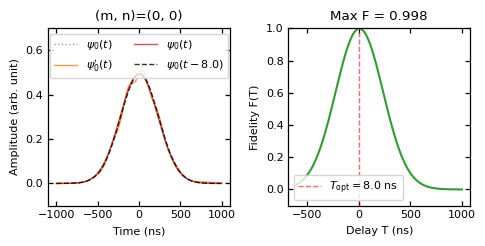

best_x: [-8.]


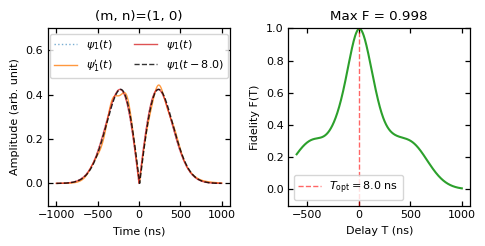

best_x: [-9.]


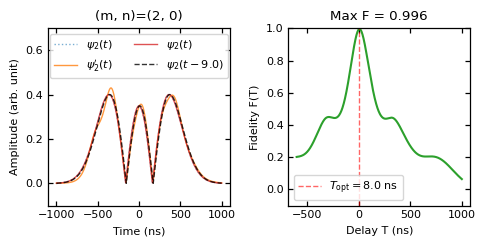

best_x: [-10.]


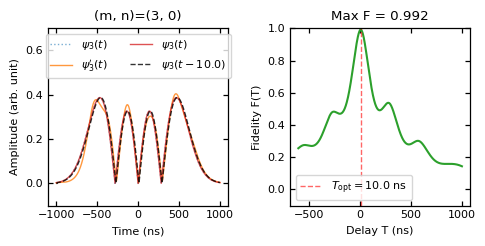

best_x: [-13.]


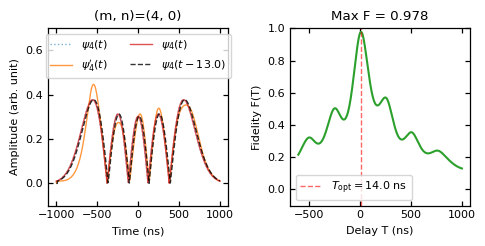

best_x: [-20.]


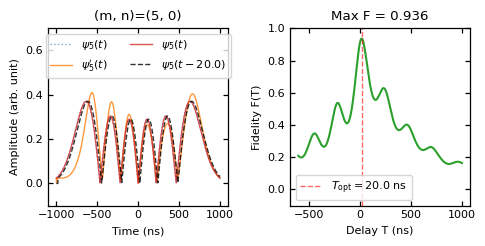

best_x: [-38.]


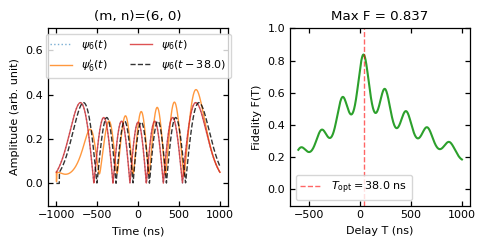

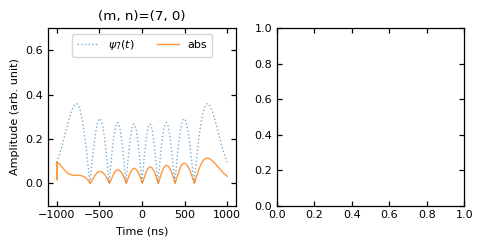

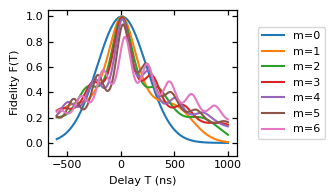

In [21]:
all_F_vals = []
mode_labels = []

for m in range(8):    
    fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
    plt.subplots_adjust(wspace=0.4)

    n=0
    states = results[(m, n)].states
    vcdvc_s = qt.expect(vc.dag() * vc, states)
    ada_s = qt.expect(a.dag() * a, states)
    vcda_s = qt.expect(vc.dag() * a, states)
    advc_s = qt.expect(a.dag() * vc, states)
    args = {
        "center": 0.0,
        "fogi_mode": n,
        "g_interps": g_interps,
        "g_interps_rvs": g_interps_rvs,
        "g_u_interps": g_u_interps,
        "input_num": m,
        "input": 0,
    }  

    gu_values = np.array([g_u(t, args) for t in tgrid])
    LdL = (
        gu_values * np.conjugate(gu_values) * vcdvc_s
        + kappa_r * ada_s
        + np.sqrt(kappa_r) * (gu_values * vcda_s + np.conjugate(gu_values) * advc_s)
    )
    input_xi = hermite(tgrid, m, kappa_ph)
    
    axes[0].plot(tgrid, np.abs(input_xi)*1e1, lw=1, alpha=0.6, color="tab:blue", linestyle=":", label=rf"$\psi_{m}(t)$")
    if m ==7:
        axes[0].plot(tgrid, np.abs(np.sqrt(LdL))*1e1, lw=1, alpha=0.8, color="tab:orange", label="abs")
    if m < 7:
        axes[0].plot(tgrid, np.abs(np.sqrt(LdL))*1e1, lw=1, alpha=0.8, color="tab:orange", label=rf"$\psi_{m}'(t)$")
        nonshifted_xi = hermite(tgrid, m, kappa_ph)
        axes[0].plot(tgrid, np.abs(nonshifted_xi)*1e1, lw=1, alpha=0.8, color="tab:red", label= rf"$\psi_{m}(t)$")

        fitted_dummy, best_x = fit_delay(tgrid, np.sqrt(LdL), nonshifted_xi, x0=[-50])
        shift_val = best_x
        def apply_fit(waveform, shift_val, time):
            waveform_resampled = np.interp(time, np.linspace(time[0], time[-1], len(waveform)), waveform)
            dt = time[1] - time[0]
            shift_idx = -shift_val / dt 
            return nd_shift(waveform_resampled, shift=shift_idx, mode='constant', cval=0.0)
        
        delay_opt_waveform = apply_fit(nonshifted_xi, shift_val*2, tgrid)
        axes[0].plot(tgrid, np.abs(delay_opt_waveform)*1e1, lw=1, alpha=0.8, color="black", linestyle="--", label=rf"$\psi_{m}(t{round(shift_val[0]*2, 0)})$")

        T_vals = np.linspace(-600, 1000, 801)  # ns範囲
        F_vals = fidelity_vs_delay(tgrid, np.sqrt(LdL), np.abs(nonshifted_xi), -T_vals)
        all_F_vals.append(F_vals)
        mode_labels.append(f"m={m}")
        axes[1].plot(T_vals, F_vals, lw=1.5, color="tab:green")
        axes[1].set_xlabel("Delay T (ns)")
        axes[1].set_ylabel("Fidelity F(T)")
        axes[1].set_ylim(-0.1, 1)
        axes[1].set_title("Fidelity vs Delay")
        F_max = F_vals.max()
        T_opt = T_vals[F_vals.argmax()]
        axes[1].axvline(T_opt, color="red", linestyle="--", alpha=0.6, label=fr"$T_\mathrm{{opt}}={T_opt:.1f}$ ns")
        axes[1].legend(loc="lower left",)
        axes[1].set_title(fr"Max F = {F_max:.3f}")
     
    axes[0].set_xlabel(r"Time (ns)")
    axes[0].set_ylim(-0.1, 0.7)
    if n == 0:
        axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1), ncol=2)
        axes[0].set_ylabel("Amplitude (arb. unit)")
        axes[0].set_title(f"(m, n)=({m}, {n})")
    else:
        axes[0].set_title(f"({m}, {n})")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(4,2))
for F_vals, label in zip(all_F_vals, mode_labels):
    plt.plot(T_vals, F_vals, lw=1.5, label=label)
plt.xlabel("Delay T (ns)")
plt.ylabel("Fidelity F(T)")
plt.ylim(-0.1, 1.05)
# plt.title("Fidelity vs Delay for all modes")
plt.legend(loc="center right", bbox_to_anchor=(1.5, 0.5), ncol=1)
plt.tight_layout()
plt.show()

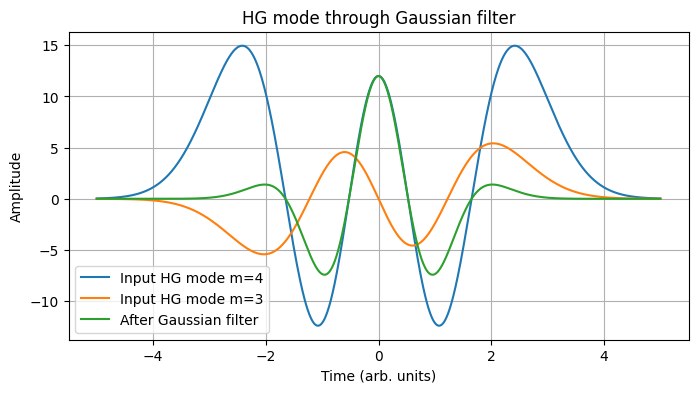

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite

# --- パラメータ ---
num_modes = 5       # 計算するHGモードの最大次数
t_min, t_max = -5, 5
num_points = 1000
t = np.linspace(t_min, t_max, num_points)

# --- HGモード関数 ---
def HG_mode(m, t, sigma=1.0):
    Hm = hermite(m)
    return Hm(t/sigma) * np.exp(-t**2/(2*sigma**2))

# --- ガウシアンフィルタ ---
sigma_filt = 1  # フィルタ幅
gaussian_filter = np.exp(-t**2/(2*sigma_filt**2))

# --- 可視化する入力モードを選択 ---
m_in = 4
psi_in = HG_mode(m_in, t)
psi_filtered = psi_in * gaussian_filter  # フィルタを通した波形

psi_in1 = HG_mode(m_in-1, t)
# psi_filtered = psi_in * gaussian_filter  # フィルタを通した波形

# --- プロット ---
plt.figure(figsize=(8,4))
plt.plot(t, psi_in, label=f"Input HG mode m={m_in}")
plt.plot(t, psi_in1, label=f"Input HG mode m={m_in-1}")
plt.plot(t, psi_filtered, label="After Gaussian filter")
plt.xlabel("Time (arb. units)")
plt.ylabel("Amplitude")
plt.title("HG mode through Gaussian filter")
plt.legend()
plt.grid(True)
plt.show()
